# Score из диффузионной модели на шумном торе с двумя кластерами

Постановка задачи: $s(x)$ берётся из **обученной диффузионной модели** $s_\theta(x, \tau) \approx \nabla_x \log p_\tau(x)$, без знания истинного распределения. Тестируем именно эту цепочку.

### Датасет
Двумерное многообразие — тор в $\mathbb{R}^3$:
$$
\gamma(\theta, \varphi) = \big((R + r\cos\theta)\cos\varphi,\ (R+r\cos\theta)\sin\varphi,\ r\sin\theta\big), \qquad R=1,\ r=0.4.
$$
**Неравномерная плотность**: $(\theta, \varphi)$ выбирается из смеси двух гауссиан с центрами $(0, 0)$ и $(\pi, \pi)$ — два кластера на противоположных сторонах тора. Сверху изотропный шум $\sigma_{\mathrm{noise}} = 0.15$ в $\mathbb{R}^3$ — точки отклоняются от поверхности тора - двухмеерная структура теряется, и метрика должна сама её восстановить.

Внутренняя размерность данных $= 2$, объемлющая $= 3$, плюс есть нетривиальная кластерная структура внутри многообразия.

### План
1. Сэмплировать данные, визуализировать тор с кластерами.
2. Обучить маленькую MLP-диффузионную модель $s_\theta(x, \sigma)$ через стандартный denoising score matching.
3. Использовать обученный $s_\theta$ для построения score-induced метрики $g(x) = (I + s_\theta(x)\, s_\theta(x)^\top)^{-1}$.
4. Сравнить heat-kernel и $C(X; t)$ под евклидовой vs score-induced метриками.
5. Рост $C(X; t = 1/\lambda_2)$ при $N \to \infty$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn

R, r = 1.0, 0.4
sigma_noise = 0.15


def sample_two_clusters_torus(n, R=R, r=r, sigma_noise=sigma_noise, cluster_sigma=0.45, rng=None):
    rng = rng if rng is not None else np.random.default_rng(0)
    centers = np.array([[0.0, 0.0], [np.pi, np.pi]])
    k = rng.integers(0, 2, n)
    theta = centers[k, 0] + rng.normal(0, cluster_sigma, n)
    phi = centers[k, 1] + rng.normal(0, cluster_sigma, n)
    x = (R + r * np.cos(theta)) * np.cos(phi)
    y = (R + r * np.cos(theta)) * np.sin(phi)
    z = r * np.sin(theta)
    pts = np.stack([x, y, z], axis=1)
    pts += sigma_noise * rng.standard_normal((n, 3))
    return pts, k


def berry_sauer_general(X, eps, alpha=1.0, dist_sq=None):
    if dist_sq is None:
        dist_sq = np.sum((X[:, None] - X[None]) ** 2, axis=-1)
    K = np.exp(-dist_sq / eps)
    q = K.sum(axis=1) ** alpha
    K_a = K / np.outer(q, q)
    d = K_a.sum(axis=1)
    d_inv_sqrt = 1.0 / np.sqrt(d)
    K_norm = K_a * np.outer(d_inv_sqrt, d_inv_sqrt)
    n = X.shape[0]
    L_sym = (np.eye(n) - K_norm) / eps
    return 0.5 * (L_sym + L_sym.T)


def discrete_heat_kernel(L_sym, t):
    w, V = np.linalg.eigh(L_sym)
    return (V * np.exp(-t * w)) @ V.T


def normalise_pointwise(K):
    d = np.sqrt(np.clip(np.diag(K), 1e-15, None))
    return K / np.outer(d, d)


def complexity(K, jitter=1e-10):
    n = K.shape[0]
    M = np.eye(n) + K + jitter * np.eye(n)
    L = np.linalg.cholesky(M)
    return float(2.0 * np.sum(np.log(np.diag(L))))


def metric_from_score(s_vec):
    n, d = s_vec.shape
    g = np.empty((n, d, d))
    I = np.eye(d)
    for i in range(n):
        g[i] = np.linalg.inv(I + np.outer(s_vec[i], s_vec[i]))
    return g


def metric_distances_sq(X, g):
    g_avg = 0.5 * (g[:, None] + g[None, :])
    diff = X[:, None] - X[None, :]
    return np.einsum('ijk, ijkl, ijl -> ij', diff, g_avg, diff)


## Данные


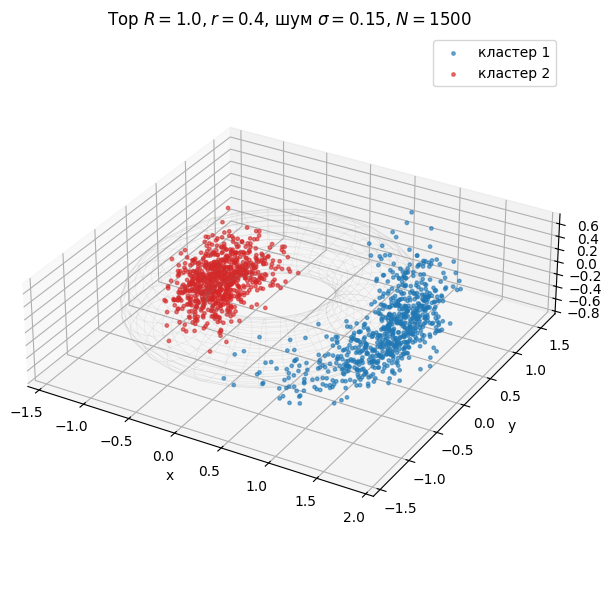

In [2]:
rng = np.random.default_rng(0)
X_show, k_show = sample_two_clusters_torus(1500, rng=rng)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
# torus wireframe
u, v = np.mgrid[0:2*np.pi:30j, 0:2*np.pi:30j]
ax.plot_wireframe((R + r*np.cos(u))*np.cos(v),
                  (R + r*np.cos(u))*np.sin(v),
                  r*np.sin(u),
                  color='gray', alpha=0.15, linewidth=0.4)
for c, col in zip([0, 1], ['C0', 'C3']):
    mask_c = (k_show == c)
    ax.scatter(X_show[mask_c, 0], X_show[mask_c, 1], X_show[mask_c, 2], s=6, c=col, alpha=0.6, label=fr'кластер {c+1}')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_title(fr'Тор $R={R}, r={r}$, шум $\sigma={sigma_noise}$, $N=1500$')
ax.legend()
ax.set_box_aspect((1, 1, 0.3))
plt.tight_layout(); plt.show()


## Обучение диффузионной модели

Маленькая MLP $s_\theta(x, \sigma): \mathbb{R}^3 \times \mathbb{R}_+ \to \mathbb{R}^3$ через denoising score matching:
$$
\mathcal{L}(\theta) \;=\; \mathbb{E}_{x \sim p_0,\ \sigma \sim p(\sigma),\ \epsilon \sim \mathcal{N}(0, I)}
\Big\|\sigma\, s_\theta(x + \sigma \epsilon,\ \sigma) + \epsilon \Big\|^2.
$$
При сходимости $s_\theta(x, \sigma) \approx \nabla_x \log p_\sigma(x)$, где $p_\sigma = p_0 \ast \mathcal{N}(0, \sigma^2 I)$. Для оценки score самого распределения берём малое $\sigma_{\mathrm{eval}}$.


training on 8000 samples...


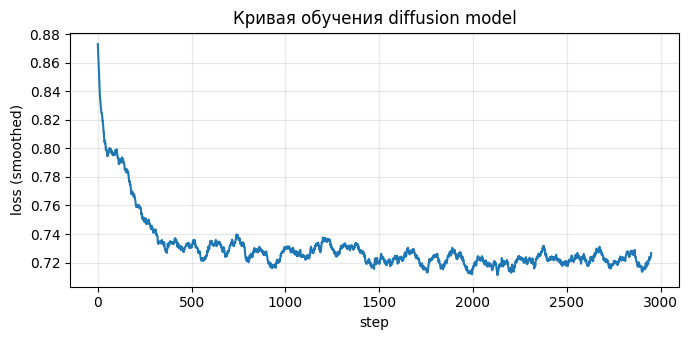

final loss = 0.7267


In [3]:
class ScoreNet(nn.Module):
    def __init__(self, d=3, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, d),
        )

    def forward(self, x, log_sigma):
        return self.net(torch.cat([x, log_sigma], dim=-1))


def train_score(X, n_steps=3000, batch=512, lr=2e-3, sigma_min=0.01, sigma_max=1.0, seed=0):
    torch.manual_seed(seed)
    model = ScoreNet()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X_t = torch.tensor(X, dtype=torch.float32)
    log_smin, log_smax = float(np.log(sigma_min)), float(np.log(sigma_max))
    losses = []
    for step in range(n_steps):
        idx = torch.randint(0, len(X_t), (batch,))
        x = X_t[idx]
        log_sigma = torch.rand(batch, 1) * (log_smax - log_smin) + log_smin
        sigma = torch.exp(log_sigma)
        eps = torch.randn_like(x)
        x_noisy = x + sigma * eps
        pred = model(x_noisy, log_sigma)
        loss = ((sigma * pred + eps) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return model, np.array(losses)


def eval_score(X_np, model, sigma_eval=0.05):
    Xt = torch.tensor(X_np, dtype=torch.float32)
    log_sigma = torch.full((Xt.shape[0], 1), float(np.log(sigma_eval)))
    with torch.no_grad():
        return model(Xt, log_sigma).numpy()


X_train, _ = sample_two_clusters_torus(8000, rng=np.random.default_rng(1))
print(f"training on {len(X_train)} samples...")
model, losses = train_score(X_train, n_steps=3000)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.convolve(losses, np.ones(50)/50, mode='valid'))
ax.set_xlabel('step'); ax.set_ylabel('loss (smoothed)')
ax.set_title('Кривая обучения diffusion model')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"final loss = {losses[-50:].mean():.4f}")


## Проверка выученного score

Визуализируем $s_\theta(x, \sigma_{\mathrm{eval}})$ как стрелки. Ожидаем: вектор направлен ортог. к поверхности тора + к ближайшему кластеру.


|score| at sigma_eval=0.05: median=6.37, 5-95%: [2.17, 11.66]


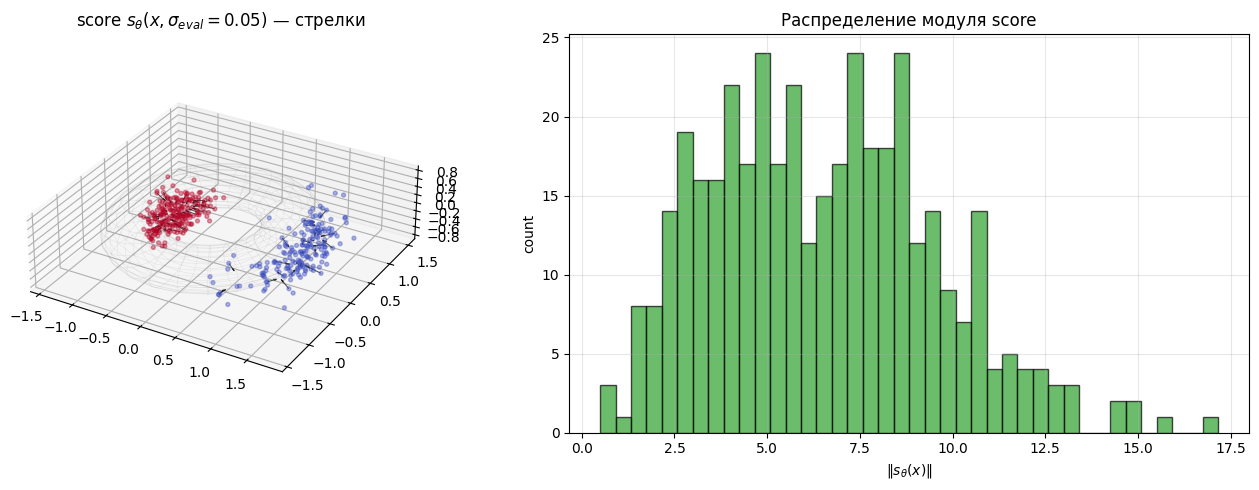

In [4]:
sigma_eval = 0.05
X_eval, k_eval = sample_two_clusters_torus(400, rng=np.random.default_rng(7))
s_eval = eval_score(X_eval, model, sigma_eval=sigma_eval)
s_mag = np.linalg.norm(s_eval, axis=1)
print(f"|score| at sigma_eval={sigma_eval}: median={np.median(s_mag):.2f}, "
      f"5-95%: [{np.percentile(s_mag, 5):.2f}, {np.percentile(s_mag, 95):.2f}]")

sub = np.random.default_rng(0).choice(len(X_eval), 80, replace=False)
arrow_scale = 0.02

fig = plt.figure(figsize=(14, 5))

ax = fig.add_subplot(121, projection='3d')
u, v = np.mgrid[0:2*np.pi:25j, 0:2*np.pi:25j]
ax.plot_wireframe((R + r*np.cos(u))*np.cos(v), (R + r*np.cos(u))*np.sin(v), r*np.sin(u), color='gray', alpha=0.15, linewidth=0.4)
ax.scatter(X_eval[:, 0], X_eval[:, 1], X_eval[:, 2], s=8, c=k_eval, cmap='coolwarm', alpha=0.4)
for i in sub:
    p = X_eval[i]; v_ = arrow_scale * s_eval[i]
    ax.quiver(p[0], p[1], p[2], v_[0], v_[1], v_[2],
              color='black', alpha=0.7, lw=0.7)
ax.set_box_aspect((1, 1, 0.3))
ax.set_title(r'score $s_\theta(x, \sigma_{eval}=0.05)$ — стрелки')

ax = fig.add_subplot(122)
ax.hist(s_mag, bins=40, color='C2', edgecolor='black', alpha=0.7)
ax.set_xlabel(r'$\|s_\theta(x)\|$')
ax.set_ylabel('count')
ax.set_title('Распределение модуля score')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Метрические шары в нескольких точках
рисуем сами **метрические шары** $\{v : (v-x_i)^\top g(x_i)\,(v-x_i) = r^2\}$ в нескольких точках обоих кластеров. Под евклидовой метрикой это сферы, под score-induced — эллипсоиды, вытянутые вдоль локального score (наружу нормали к тору).

N=400, eps_eucl=0.4577, eps_score=0.1979


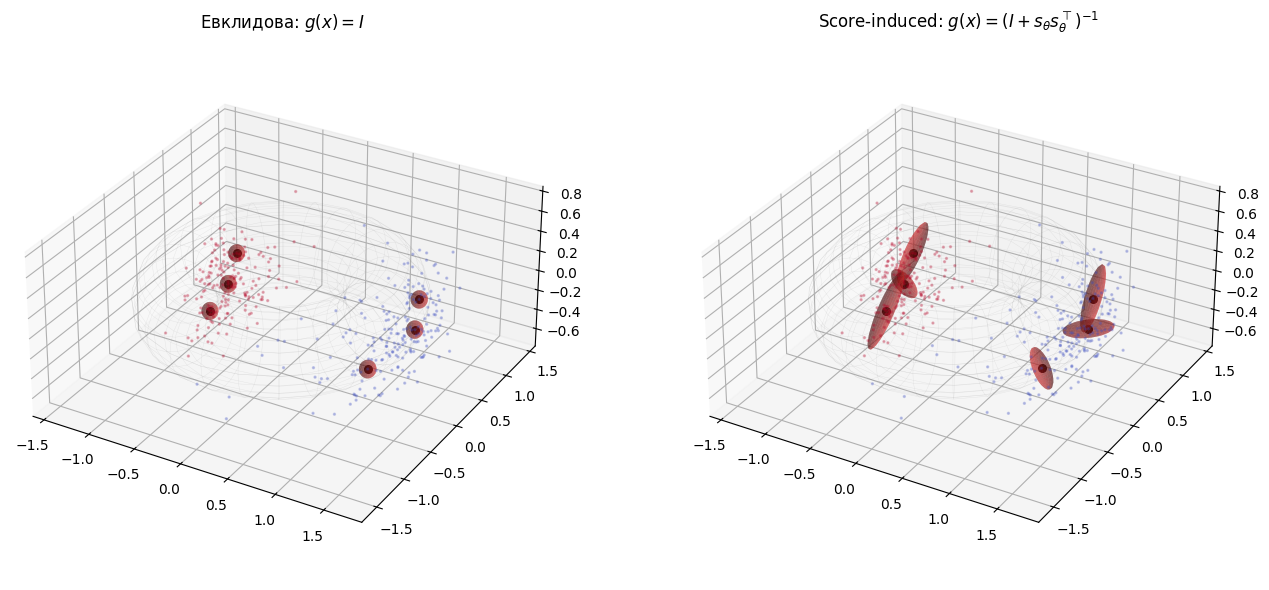


Эллипсоид имеет полуоси r / sqrt(eig(g)). Для score-induced:
  - перпендикулярно s: полуось = r (евклидова)
  - вдоль s: полуось = r * sqrt(1 + |s|^2)  ->  вытянут в направлении score
  точка #332: |s|=3.53, вытянутость = sqrt(1+|s|^2) = 3.67
  точка #356: |s|=4.22, вытянутость = sqrt(1+|s|^2) = 4.34
  точка #146: |s|=3.48, вытянутость = sqrt(1+|s|^2) = 3.63


In [5]:
N = 400
X, k_id = sample_two_clusters_torus(N, rng=np.random.default_rng(42))
s_X = eval_score(X, model, sigma_eval=sigma_eval)
g_X = metric_from_score(s_X)

d2_eucl = np.sum((X[:, None] - X[None]) ** 2, axis=-1)
d2_score = metric_distances_sq(X, g_X)
mask = ~np.eye(N, dtype=bool)
eps_e = np.median(d2_eucl[mask]) / 5
eps_s = np.median(d2_score[mask]) / 5
print(f"N={N}, eps_eucl={eps_e:.4f}, eps_score={eps_s:.4f}")

L_e = berry_sauer_general(X, eps_e)
L_s = berry_sauer_general(X, eps_s, dist_sq=d2_score)


def ellipsoid_surface(center, g, radius=0.08, n_u=24, n_v=12):
    """v: (v-c)^T g (v-c) = radius^2"""
    w, V = np.linalg.eigh(g)
    axes_lens = radius / np.sqrt(np.maximum(w, 1e-12))
    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)
    U, Vp = np.meshgrid(u, v)
    x_loc = axes_lens[0] * np.cos(U) * np.sin(Vp)
    y_loc = axes_lens[1] * np.sin(U) * np.sin(Vp)
    z_loc = axes_lens[2] * np.cos(Vp)
    local = np.stack([x_loc, y_loc, z_loc], axis=-1)
    rot = local @ V.T
    return (center[0] + rot[..., 0],
            center[1] + rot[..., 1],
            center[2] + rot[..., 2])


target_angles = [(0.0, 0.0), (0.4, 0.3), (-0.3, -0.4),
                 (np.pi, np.pi), (np.pi + 0.3, np.pi + 0.4), (np.pi - 0.4, np.pi - 0.3)]
target_idxs = []
for theta_t, phi_t in target_angles:
    p = np.array([(R + r * np.cos(theta_t)) * np.cos(phi_t),
                  (R + r * np.cos(theta_t)) * np.sin(phi_t),
                  r * np.sin(theta_t)])
    target_idxs.append(int(np.argmin(np.linalg.norm(X - p, axis=1))))

g_eye = np.tile(np.eye(3), (N, 1, 1))
rad_ball = 0.08

fig = plt.figure(figsize=(14, 6))
for j, (title, g_field) in enumerate([
        ('Евклидова: $g(x) = I$', g_eye),
        (r'Score-induced: $g(x) = (I + s_\theta s_\theta^\top)^{-1}$', g_X)]):
    ax = fig.add_subplot(1, 2, j + 1, projection='3d')
    u_t, v_t = np.mgrid[0:2*np.pi:25j, 0:2*np.pi:25j]
    ax.plot_wireframe((R + r*np.cos(u_t))*np.cos(v_t), (R + r*np.cos(u_t))*np.sin(v_t), r*np.sin(u_t), color='gray', alpha=0.15, linewidth=0.3)
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c=k_id, cmap='coolwarm', alpha=0.25)
    for i in target_idxs:
        Xb, Yb, Zb = ellipsoid_surface(X[i], g_field[i], radius=rad_ball)
        ax.plot_surface(Xb, Yb, Zb, color='C3', alpha=0.45, linewidth=0, edgecolor='none')
        ax.scatter(*X[i], c='black', s=30, marker='o')
    ax.set_box_aspect((1, 1, 0.5))
    ax.set_title(title)
plt.tight_layout(); plt.show()

# print("\nЭллипсоид имеет полуоси r / sqrt(eig(g)). Для score-induced:")
# print("  - перпендикулярно s: полуось = r (евклидова)")
# print("  - вдоль s: полуось = r * sqrt(1 + |s|^2)  ->  вытянут в направлении score")
# for i in target_idxs[:3]:
#     s_norm = float(np.linalg.norm(s_X[i]))
#     print(f"  точка #{i}: |s|={s_norm:.2f}, вытянутость = sqrt(1+|s|^2) = {np.sqrt(1+s_norm**2):.2f}")


## Сравнение $C(X; t)$: евклидова vs score-induced

Сканируем $t$ в широком диапазоне и считаем $C(X; t) = \log\det(I + K_t)$ для двух выборов метрики в базовом ядре Berry–Sauer.

Данные лежат на $2$-мерной поверхности тора в $\mathbb R^3$, причём в двух кластерах. Под евклидовой метрикой ядро Berry–Sauer видит геометрию $\mathbb R^3$: пары точек, оказавшиеся близко считаются похожими, хотя по поверхности до них м. б. далеко. Это завышает число различимых мерой точек и, соответственно, $C(X)$.

Score-метрика $g = (I + s s^\top)^{-1}$ устроена так, что $|s| = |\nabla\log p|$ велик в **нормальном** к многообразию направлении. Соответствующее собственное значение $g$ — $1/(1 + |s|^2) \ll 1$, то есть **расстояния в нормальном направлении сильно сжимаются**. Тангенциальные направления сжимаются слабо. В итоге $d_g$ хорошо аппроксимирует внутреннюю метрику $2$-мерного многообразия.

Из этого следует:
- $K_{\rm score}$ агрегирует точки, действительно близкие **по многообразию**, $\Rightarrow$ у $K$ низкий эффективный ранг $\Rightarrow$ $C_{\rm score}$ мало.
- $K_{\rm eucl}$ «не видит» поверхности, считает многие межтрубочные пары далёкими $\Rightarrow$ K ближе к $I$ $\Rightarrow$ $C_{\rm eucl}$ велико.

Разница должна быть максимальной на промежуточных $t$. На малых $t$ оба ядра близки к $I$ ($C \approx N\log 2$). На больших $t$ оба сходятся к $\log(1 + N)$ (один связный компонент).

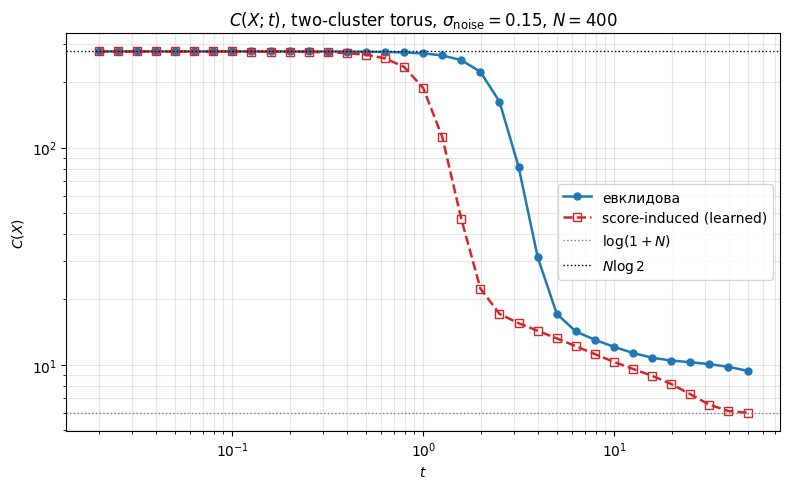

        t     C_eucl    C_score   C_e - C_s
   0.0200    277.258    277.254       0.004
   0.0252    277.258    277.251       0.007
   0.0317    277.257    277.246       0.011
   0.0399    277.255    277.237       0.018
   0.0502    277.253    277.224       0.029
   0.0632    277.250    277.202       0.048
   0.0796    277.245    277.165       0.079
   0.1001    277.236    277.103       0.133
   0.1261    277.222    276.997       0.225
   0.1587    277.198    276.811       0.387
   0.1997    277.159    276.479       0.680
   0.2514    277.091    275.868       1.223
   0.3164    276.974    274.708       2.266
   0.3983    276.768    272.422       4.347
   0.5014    276.394    267.721       8.673
   0.6311    275.695    257.625      18.070
   0.7944    274.339    235.308      39.030
   1.0000    271.596    188.138      83.458
   1.2587    265.771    111.951     153.819
   1.5845    252.780     46.853     205.927
   1.9944    223.229     22.433     200.796
   2.5105    162.799     17.153 

In [6]:
ts = np.geomspace(2e-2, 50, 35)
C_e, C_s = [], []
for t in ts:
    C_e.append(complexity(normalise_pointwise(discrete_heat_kernel(L_e, t))))
    C_s.append(complexity(normalise_pointwise(discrete_heat_kernel(L_s, t))))
C_e = np.array(C_e); C_s = np.array(C_s)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts, C_e, 'o-', color='C0', ms=5, lw=1.8, label='евклидова')
ax.plot(ts, C_s, 's--', color='C3', ms=6, lw=1.8, mfc='none', label='score-induced (learned)')
ax.axhline(np.log(1 + N), color='gray', ls=':', lw=1.0, label=r'$\log(1+N)$')
ax.axhline(N * np.log(2), color='black', ls=':', lw=1.0, label=r'$N\log 2$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$t$'); ax.set_ylabel(r'$C(X)$')
ax.set_title(fr'$C(X; t)$, two-cluster torus, $\sigma_{{\rm noise}}=0.15$, $N={N}$')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

print(f"{'t':>9} {'C_eucl':>10} {'C_score':>10} {'C_e - C_s':>11}")
for t, ce, cs in zip(ts, C_e, C_s):
    print(f'{t:>9.4f} {ce:>10.3f} {cs:>10.3f} {ce-cs:>11.3f}')


## Асимптотика $C(X)$ при $N \to \infty$

Берём два естественных выбора $t$, инвариантных по $N$:
1. $t = 1/\lambda_2$;
2. $t = \operatorname{median}(d_g^2)$.

Оба должны иметь $N$-независимый предел при $N \to \infty$. Смотрим, как ведёт себя $C(X)$ при росте $N$ под каждой шкалой.

N=  200: t_spec= 5.197, C_spec= 10.532  |  t_med= 0.914, C_med= 79.390
N=  400: t_spec= 4.749, C_spec= 12.896  |  t_med= 0.964, C_med=188.417


N=  800: t_spec= 6.343, C_spec= 13.635  |  t_med= 0.952, C_med=437.129


N= 1200: t_spec= 5.736, C_spec= 15.687  |  t_med= 0.959, C_med=699.403


N= 1600: t_spec= 4.893, C_spec= 16.931  |  t_med= 0.918, C_med=968.636


N= 2000: t_spec= 5.163, C_spec= 17.945  |  t_med= 0.946, C_med=1239.164


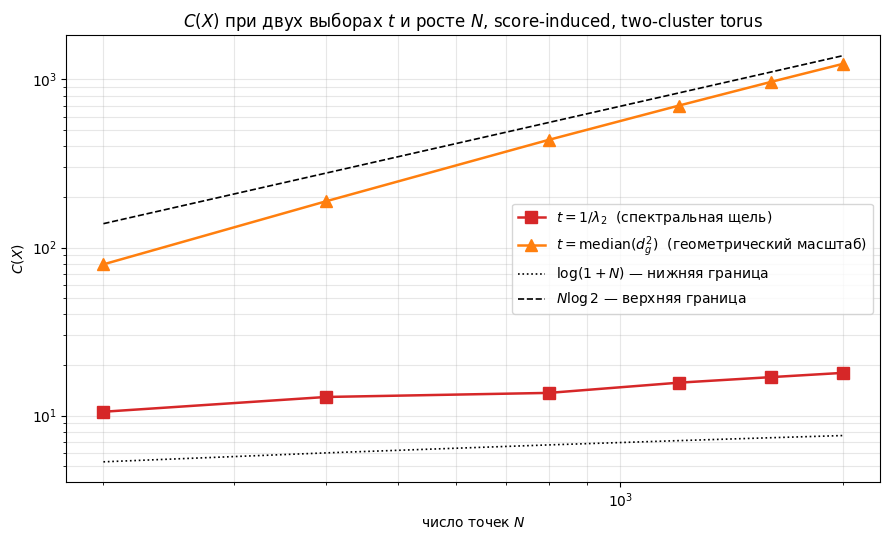


     N    t_spec    C_spec     t_med     C_med   log(1+N)
   200     5.197    10.532     0.914    79.390      5.303
   400     4.749    12.896     0.964   188.417      5.994
   800     6.343    13.635     0.952   437.129      6.686
  1200     5.736    15.687     0.959   699.403      7.091
  1600     4.893    16.931     0.918   968.636      7.378
  2000     5.163    17.945     0.946  1239.164      7.601


In [7]:
def t_spectral(L):
    w = np.sort(np.linalg.eigvalsh(L))
    nz = w[w > 1e-9]
    return float(1.0 / nz[0]) if len(nz) else float('inf')


def t_median(d2):
    n = d2.shape[0]
    mask = ~np.eye(n, dtype=bool)
    return float(np.median(d2[mask]))


Ns = np.array([200, 400, 800, 1200, 1600, 2000])
C_spec = []
C_med = []
t_spec_list = []
t_med_list = []
for Nv in Ns:
    Xv, _ = sample_two_clusters_torus(int(Nv), rng=np.random.default_rng(int(Nv)))
    s_Xv = eval_score(Xv, model, sigma_eval=sigma_eval)
    g_Xv = metric_from_score(s_Xv)
    d2s_v = metric_distances_sq(Xv, g_Xv)
    mask_v = ~np.eye(int(Nv), dtype=bool)
    eps_s_v = np.median(d2s_v[mask_v]) / 5
    Ls_v = berry_sauer_general(Xv, eps_s_v, dist_sq=d2s_v)

    tsp = t_spectral(Ls_v)
    tmd = t_median(d2s_v)
    t_spec_list.append(tsp)
    t_med_list.append(tmd)

    C_spec.append(complexity(normalise_pointwise(discrete_heat_kernel(Ls_v, tsp))))
    C_med.append(complexity(normalise_pointwise(discrete_heat_kernel(Ls_v, tmd))))
    print(f'N={int(Nv):>5d}: t_spec={tsp:>6.3f}, C_spec={C_spec[-1]:>7.3f}  |  '
          f't_med={tmd:>6.3f}, C_med={C_med[-1]:>7.3f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(Ns, C_spec, 's-', color='C3', ms=9, lw=1.8,
        label=r'$t = 1/\lambda_2$')
ax.plot(Ns, C_med, '^-', color='C1', ms=9, lw=1.8,
        label=r'$t = \operatorname{median}(d_g^2)$')
ax.plot(Ns, np.log(1 + Ns), 'k:', lw=1.2, label=r'$\log(1+N)$ — нижняя граница')
ax.plot(Ns, Ns * np.log(2), 'k--', lw=1.2, label=r'$N\log 2$ — верхняя граница')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('число точек $N$'); ax.set_ylabel(r'$C(X)$')
ax.set_title(r'$C(X)$ при двух выборах $t$ и росте $N$, score-induced, two-cluster torus')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

# print()
# print(f"{'N':>6} {'t_spec':>9} {'C_spec':>9} {'t_med':>9} {'C_med':>9} "
#       f"{'log(1+N)':>10}")
# for i, Nv in enumerate(Ns):
#     print(f'{int(Nv):>6d} {t_spec_list[i]:>9.3f} {C_spec[i]:>9.3f} '
#           f'{t_med_list[i]:>9.3f} {C_med[i]:>9.3f} {np.log(1+Nv):>10.3f}')


## Малые $N$: рост $C(X; t = 1/\lambda_2)$ и выход на огибающую

Чтобы увидеть, как сложность набирается с самого начала, отдельно сканируем $N \in [2, 100]$. У данных **ровно $N_c = 2$ кластера**, и если score-метрика + Berry–Sauer действительно распознают эту структуру, то $C(X)$ должно идти вдоль огибающей **$N_c\log(1+N/N_c)$** — это значение log-det для блочно-диагонального ядра из $N_c$ rank-1 блоков размера $N/N_c$.

Усреднение по $20$ сидам.

N=   2: C(t_spec)= 1.331 ± 0.000
N=   3: C(t_spec)= 1.726 ± 0.018
N=   4: C(t_spec)= 2.027 ± 0.047
N=   5: C(t_spec)= 2.450 ± 0.255
N=   6: C(t_spec)= 2.643 ± 0.197
N=   7: C(t_spec)= 2.880 ± 0.181
N=   8: C(t_spec)= 3.021 ± 0.213
N=  10: C(t_spec)= 3.487 ± 0.218
N=  12: C(t_spec)= 3.663 ± 0.224
N=  15: C(t_spec)= 4.225 ± 0.316
N=  18: C(t_spec)= 4.427 ± 0.280
N=  20: C(t_spec)= 4.781 ± 0.259
N=  25: C(t_spec)= 5.169 ± 0.293
N=  30: C(t_spec)= 5.516 ± 0.367
N=  40: C(t_spec)= 6.152 ± 0.515
N=  50: C(t_spec)= 6.823 ± 0.441
N=  70: C(t_spec)= 7.534 ± 0.440
N= 100: C(t_spec)= 8.607 ± 0.612


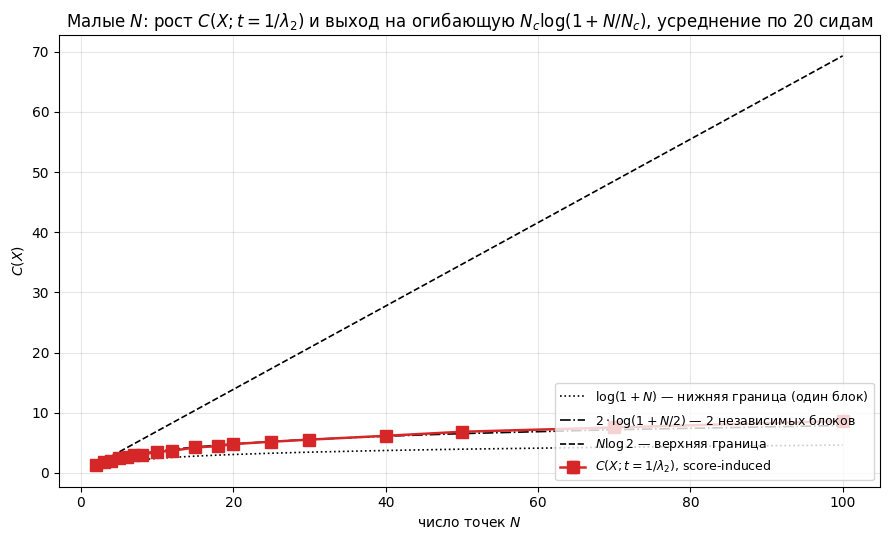

In [8]:
Ns_small = np.array([2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20, 25, 30, 40, 50, 70, 100])
n_seeds = 20
C_small_mean = []
C_small_std = []
for Nv in Ns_small:
    C_runs = []
    for seed in range(n_seeds):
        Xv, _ = sample_two_clusters_torus(int(Nv),
                                          rng=np.random.default_rng(1000 * int(Nv) + seed))
        s_Xv = eval_score(Xv, model, sigma_eval=sigma_eval)
        g_Xv = metric_from_score(s_Xv)
        d2s_v = metric_distances_sq(Xv, g_Xv)
        mask_v = ~np.eye(int(Nv), dtype=bool)
        med = np.median(d2s_v[mask_v]) if mask_v.any() else 1.0
        eps_s_v = max(med / 5, 1e-6)
        Ls_v = berry_sauer_general(Xv, eps_s_v, dist_sq=d2s_v)
        tsp = t_spectral(Ls_v)
        H = discrete_heat_kernel(Ls_v, tsp)
        C_runs.append(complexity(normalise_pointwise(H)))
    C_small_mean.append(float(np.mean(C_runs)))
    C_small_std.append(float(np.std(C_runs)))
    # print(f"N={int(Nv):>4d}: C(t_spec)={C_small_mean[-1]:>6.3f} "
    #       f"+-{C_small_std[-1]:>5.3f}")

N_c = 2  # количество кластеров в данных

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(Ns_small, C_small_mean, yerr=C_small_std, fmt="s-", color="C3", ms=8, lw=1.8, capsize=3, label=r"$C(X; t=1/\lambda_2)$, score-induced")
ax.plot(Ns_small, np.log(1 + Ns_small), "k:", lw=1.2, label=r"$\log(1+N)$ — нижняя граница (один блок)")
ax.plot(Ns_small, N_c * np.log(1 + Ns_small / N_c), "k-.", lw=1.2, label=fr"${N_c}\cdot\log(1+N/{N_c})$ — ${N_c}$ независимых блоков")
ax.plot(Ns_small, Ns_small * np.log(2), "k--", lw=1.2, label=r"$N\log 2$ — верхняя граница")
ax.set_xlabel("число точек $N$"); ax.set_ylabel(r"$C(X)$")
ax.set_title(fr"Малые $N$: рост $C(X; t = 1/\lambda_2)$ и выход на огибающую $N_c\log(1+N/N_c)$, усреднение по {n_seeds} сидам")
ax.legend(fontsize=9, loc="lower right"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Резюме эксперимента 4

1. **Диффузионная модель** обучилась на выборке с шумного тора с двумя кластерами ($\sigma_{\mathrm{noise}} = 0.15$ — точки заметно отстоят от поверхности. Выученный score имеет направлен к поверхности тора и к ближайшему кластеру.

2. **Разница $C(X;t)$ между метриками.** В широкой полосе $t \in [1, 5]$ кривые $C_{\mathrm{eucl}}$ и $C_{\mathrm{score}}$ расходятся на порядок: евклидова метрика видит $3$-мерный объём (точки внутри ambient-шума), а score-индуцированная — внутреннюю $2$-мерную поверхность тора с кластерной структурой. При $t \to 0$ обе сходятся к $N\log 2$, при $t \to \infty$ — к $\log(1+N)$.

3. **Асимптотика $C(X)$ при $N \to \infty$ под score-метрикой.** Две $N$-независимые шкалы $t$ дают **качественно разный** рост:
   - $t = 1/\lambda_2$ стабильно по $N$: $C(X)$ растёт *сублогарифмически*. Тепловое ядро успевает усреднить по медленным модам, $C(X)$ отражает спектральную сложность многообразия.
   - $t = \operatorname{median}(d_g^2)$: $C(X)$ растёт линейно, прижимаясь к верхней границе $N\log 2$. На этом масштабе тепловое ядро ещё не успевает покрыть типичную пару точек $\Rightarrow K \approx I$, и каждая новая точка добавляет почти-полный $\log 2$.

4. **Общий вывод.** Предложенный в статье пайплайн диффузионная модель $\to$ score $\to$ score-induced метрика $\to$ Berry–Sauer $\to$ $C(X)$ работает даже на сильно зашумлённых данных сложной структуры. $C(X)$ можно вычислять для произвольных датасетов с обученным score, без предположений о геометрии.